# ITI113 MLOps Project — Responsible AI Testing

**Team:** Team 07  
**Project:** Credit-card fraud detection  
**Purpose:** AI Verify alternative covering **Fairness**, **Explainability**, and **Robustness**.

This notebook audits the same leakage-safe champion selected in Notebook 02. It:

- reconstructs the original stratified 60/20/20 split with random state 42;
- loads the champion pipeline from its recorded MLflow run;
- uses the frozen validation-selected decision threshold;
- does **not** retrain the model or tune on the test set;
- saves presentation-ready evidence to `responsible_ai_outputs/`.

> Run Notebook 02 successfully first. It must create `team07_best_model.json` and log the champion model to MLflow.


## 1. Install and Import Dependencies

In [1]:
# Restart the kernel after installation if SageMaker Studio requests it.
%pip install --quiet --upgrade fairlearn shap mlflow sagemaker-mlflow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-core 1.5.0 requires scikit-learn<1.8.0,>=1.4.0, but you have scikit-l

In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from fairlearn.metrics import MetricFrame, false_negative_rate, false_positive_rate
from sklearn.metrics import (accuracy_score,confusion_matrix,f1_score,
    precision_score,recall_score,roc_auc_score)
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## 2. Configure and Check Best Model output

In [3]:
TEAM_ID = "team07"
STUDENT_ID = "s701"
PROJECT_NAME = "credit-card-fraud-detection"
RANDOM_STATE = 42
TARGET_COLUMN = "Fraud_Label"

DATASET_CANDIDATES = [
    Path("data/fraud_dataset.csv"),
    Path("fraud_dataset.csv"),
    Path("fraud_dataset(2).csv"),
    Path("upload/fraud_dataset(2).csv"),
]
CHAMPION_CANDIDATES = [
    Path(f"{TEAM_ID}_best_model.json"),
    Path("data") / f"{TEAM_ID}_best_model.json",
]
OUTPUT_DIR = Path("responsible_ai_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def first_existing(candidates, description):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {description}. Checked: "
        + ", ".join(str(path) for path in candidates)
    )

DATASET_PATH = first_existing(DATASET_CANDIDATES, "fraud dataset")
CHAMPION_FILE = first_existing(CHAMPION_CANDIDATES, "Champion JSON")

champion = json.loads(CHAMPION_FILE.read_text(encoding="utf-8"))
required_champion_keys = {
    "best_model_uri", "decision_threshold", "test_metrics",
    "mlflow_tracking_uri", "raw_inference_columns",
}
missing_keys = sorted(required_champion_keys - set(champion))
if missing_keys:
    raise RuntimeError(f"Champion JSON is missing required keys: {missing_keys}")

BEST_MODEL_URI = champion["best_model_uri"]
BEST_THRESHOLD = float(champion["decision_threshold"])
MLFLOW_TRACKING_URI = champion["mlflow_tracking_uri"]
RAW_INFERENCE_COLUMNS = champion["raw_inference_columns"]

print("Dataset:", DATASET_PATH)
print("Champion file:", CHAMPION_FILE)
print("Algorithm:", champion.get("algorithm"))
print("MLflow model URI:", BEST_MODEL_URI)
print("Frozen threshold:", BEST_THRESHOLD)
print("Deployment ready:", champion.get("deployment_ready"))

Dataset: data/fraud_dataset.csv
Champion file: team07_best_model.json
Algorithm: XGBoost
MLflow model URI: runs:/21825ef39b7c41bdadc838f378ae6c2f/model
Frozen threshold: 0.19469599425792694
Deployment ready: True


### Audit scope and limitations

The dataset has no sex, age, race, disability, or other demographic attribute. Therefore, this notebook evaluates **operational subgroup consistency**, not demographic fairness. The selected subgroups are:

- `Location`: geographic consistency and possible geographic proxy risk;
- `Device_Type`: consistency across mobile, laptop, and tablet access;
- `Authentication_Method`: consistency across biometric, PIN, password, and OTP use.

Results from this synthetic dataset should not be presented as proof of fairness in a real banking population.


## 3. Reconstruct the leakage-safe held-out test set


In [4]:
raw_df = pd.read_csv(DATASET_PATH)

IDENTIFIER_COLUMNS = ["Transaction_ID", "User_ID"]
LEAKAGE_EXCLUDED_COLUMNS = ["Risk_Score"]
REPLACED_DATA_QUALITY_COLUMNS = ["Is_Weekend"]
RAW_TIME_COLUMN = "Timestamp"

def prepare_deployable_features(frame):
    result = frame.copy()
    timestamp = pd.to_datetime(result[RAW_TIME_COLUMN], errors="raise")
    result["Transaction_Hour"] = timestamp.dt.hour
    result["Transaction_DayOfWeek"] = timestamp.dt.dayofweek
    result["Transaction_Month"] = timestamp.dt.month
    result["Derived_Is_Weekend"] = (timestamp.dt.dayofweek >= 5).astype(int)
    result["Transaction_Hour_Sin"] = np.sin(2 * np.pi * result["Transaction_Hour"] / 24)
    result["Transaction_Hour_Cos"] = np.cos(2 * np.pi * result["Transaction_Hour"] / 24)
    return result.drop(
        columns=(IDENTIFIER_COLUMNS + LEAKAGE_EXCLUDED_COLUMNS
                 + REPLACED_DATA_QUALITY_COLUMNS
                 + [RAW_TIME_COLUMN, TARGET_COLUMN]),
        errors="ignore",
    )

X = prepare_deployable_features(raw_df)
y = raw_df[TARGET_COLUMN].astype(int)

# Reproduce Notebook 02 exactly: 80% train+validation / 20% test,
# then 75%/25% within train+validation -> 60/20/20 overall.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_val, y_train_val, test_size=0.25,
    stratify=y_train_val, random_state=RANDOM_STATE
)

if len(X_test) != 10_000:
    raise RuntimeError(f"Expected 10,000 test rows, found {len(X_test)}")

display(pd.DataFrame({
    "rows": [len(X_train), len(X_validation), len(X_test)],
    "fraud_rate": [y_train.mean(), y_validation.mean(), y_test.mean()],
}, index=["train", "validation", "test"]).style.format({"fraud_rate": "{:.2%}"}))


,rows,fraud_rate
train,30000,32.14%
validation,10000,32.13%
test,10000,32.13%


## 4. Load the champion and reproduce its frozen-threshold baseline


In [5]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
champion_model = mlflow.sklearn.load_model(BEST_MODEL_URI)

test_probability = champion_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= BEST_THRESHOLD).astype(int)

def classification_metrics(y_true, y_pred, probability=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "fpr": fp / (fp + tn) if fp + tn else np.nan,
        "fnr": fn / (fn + tp) if fn + tp else np.nan,
        "alert_rate": np.mean(y_pred),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }
    if probability is not None:
        result["auc_roc"] = roc_auc_score(y_true, probability)
    return result

baseline = classification_metrics(y_test, test_prediction, test_probability)
recorded = champion.get("test_metrics", {})

baseline_table = pd.DataFrame({
    "reproduced": {
        "recall": baseline["recall"],
        "fpr": baseline["fpr"],
        "precision": baseline["precision"],
        "f1": baseline["f1"],
        "auc_roc": baseline["auc_roc"],
    },
    "Notebook 02 recorded": {
        "recall": recorded.get("test_recall", np.nan),
        "fpr": recorded.get("test_fpr", np.nan),
        "precision": recorded.get("test_precision", np.nan),
        "f1": recorded.get("test_f1", np.nan),
        "auc_roc": recorded.get("test_auc_roc", np.nan),
    },
})
display(baseline_table.style.format("{:.4%}"))

if recorded:
    checks = {
        "recall": "test_recall", "fpr": "test_fpr",
        "precision": "test_precision", "f1": "test_f1",
    }
    mismatches = [
        name for name, recorded_name in checks.items()
        if recorded.get(recorded_name) is not None
        and not np.isclose(baseline[name], recorded[recorded_name], atol=1e-9)
    ]
    if mismatches:
        raise RuntimeError(
            "Reproduced test metrics differ from Notebook 02 for: "
            + ", ".join(mismatches)
        )

print("Confusion matrix:", {k: baseline[k] for k in ["tn", "fp", "fn", "tp"]})

,reproduced,Notebook 02 recorded
recall,63.6788%,63.6788%
fpr,4.0077%,4.0077%
precision,88.2657%,88.2657%
f1,73.9830%,73.9830%
auc_roc,81.4480%,81.4480%


Confusion matrix: {'tn': 6515, 'fp': 272, 'fn': 1167, 'tp': 2046}


# Part A — Fairness / operational subgroup consistency


### Approach justification

Fairlearn `MetricFrame` is used because it applies the same metric definitions to every subgroup. The champion model and threshold remain fixed. We emphasize:

- **Recall/FNR:** fraud missed within each group;
- **FPR:** legitimate transactions incorrectly flagged within each group;
- **Precision:** quality of fraud alerts;
- **Alert rate:** frequency with which a group is sent for intervention.

No universal fairness threshold is imposed by the assignment. The notebook reports maximum–minimum gaps and flags whether each group independently meets the existing project gates of recall ≥ 60% and FPR ≤ 5%.


In [6]:
def metric_sample_size(y_true, y_pred):
    return len(y_true)

def metric_prevalence(y_true, y_pred):
    return np.mean(y_true)

def metric_alert_rate(y_true, y_pred):
    return np.mean(y_pred)

FAIRNESS_METRICS = {
    "sample_size": metric_sample_size,
    "fraud_prevalence": metric_prevalence,
    "precision": lambda yt, yp: precision_score(yt, yp, zero_division=0),
    "recall": lambda yt, yp: recall_score(yt, yp, zero_division=0),
    "f1": lambda yt, yp: f1_score(yt, yp, zero_division=0),
    "fpr": false_positive_rate,
    "fnr": false_negative_rate,
    "alert_rate": metric_alert_rate,
}

def audit_subgroup(column):
    frame = MetricFrame(
        metrics=FAIRNESS_METRICS,
        y_true=y_test,
        y_pred=test_prediction,
        sensitive_features=X_test[column],
    )
    table = frame.by_group.copy().sort_index()
    table["recall_gate_60pct"] = table["recall"] >= 0.60
    table["fpr_gate_5pct"] = table["fpr"] <= 0.05

    gaps = pd.Series({
        "recall_gap": table["recall"].max() - table["recall"].min(),
        "fpr_gap": table["fpr"].max() - table["fpr"].min(),
        "fnr_gap": table["fnr"].max() - table["fnr"].min(),
        "precision_gap": table["precision"].max() - table["precision"].min(),
        "alert_rate_gap": table["alert_rate"].max() - table["alert_rate"].min(),
    }, name=column)
    return table, gaps

FAIRNESS_COLUMNS = ["Location", "Device_Type", "Authentication_Method"]
fairness_tables = {}
fairness_gaps = {}

for column in FAIRNESS_COLUMNS:
    table, gaps = audit_subgroup(column)
    fairness_tables[column] = table
    fairness_gaps[column] = gaps
    print(f"\n{column}")
    display(table.style.format({
        "sample_size": "{:,.0f}", "fraud_prevalence": "{:.2%}",
        "precision": "{:.2%}", "recall": "{:.2%}", "f1": "{:.2%}",
        "fpr": "{:.2%}", "fnr": "{:.2%}", "alert_rate": "{:.2%}",
    }))
    table.to_csv(OUTPUT_DIR / f"fairness_{column.lower()}.csv")

gap_table = pd.DataFrame(fairness_gaps).T
display(gap_table.style.format("{:.2%}"))
gap_table.to_csv(OUTPUT_DIR / "fairness_gap_summary.csv")



Location


,sample_size,fraud_prevalence,precision,recall,f1,fpr,fnr,alert_rate,recall_gate_60pct,fpr_gate_5pct
Location,,,,,,,,,,
London,"2,033",31.78%,89.11%,63.31%,74.03%,3.60%,36.69%,22.58%,True,True
Mumbai,"1,997",31.15%,84.65%,63.83%,72.78%,5.24%,36.17%,23.49%,True,False
New York,"1,897",31.79%,88.68%,62.35%,73.22%,3.71%,37.65%,22.35%,True,True
Sydney,"2,012",31.11%,88.91%,64.06%,74.47%,3.61%,35.94%,22.42%,True,True
Tokyo,"2,061",34.74%,89.90%,64.66%,75.22%,3.87%,35.34%,24.99%,True,True



Device_Type


,sample_size,fraud_prevalence,precision,recall,f1,fpr,fnr,alert_rate,recall_gate_60pct,fpr_gate_5pct
Device_Type,,,,,,,,,,
Laptop,"3,324",31.80%,91.60%,63.95%,75.32%,2.73%,36.05%,22.20%,True,True
Mobile,"3,377",31.71%,89.77%,62.28%,73.54%,3.30%,37.72%,22.00%,True,True
Tablet,"3,299",32.89%,83.99%,64.79%,73.15%,6.05%,35.21%,25.37%,True,False



Authentication_Method


,sample_size,fraud_prevalence,precision,recall,f1,fpr,fnr,alert_rate,recall_gate_60pct,fpr_gate_5pct
Authentication_Method,,,,,,,,,,
Biometric,"2,515",32.05%,89.33%,61.29%,72.70%,3.45%,38.71%,21.99%,True,True
OTP,"2,504",31.59%,86.19%,65.49%,74.43%,4.85%,34.51%,24.00%,True,True
PIN,"2,509",30.73%,87.30%,63.29%,73.38%,4.09%,36.71%,22.28%,True,True
Password,"2,472",34.18%,90.25%,64.62%,75.31%,3.63%,35.38%,24.47%,True,True


,recall_gap,fpr_gap,fnr_gap,precision_gap,alert_rate_gap
Location,2.31%,1.63%,2.31%,5.25%,2.64%
Device_Type,2.51%,3.32%,2.51%,7.61%,3.37%
Authentication_Method,4.20%,1.39%,4.20%,4.06%,2.49%


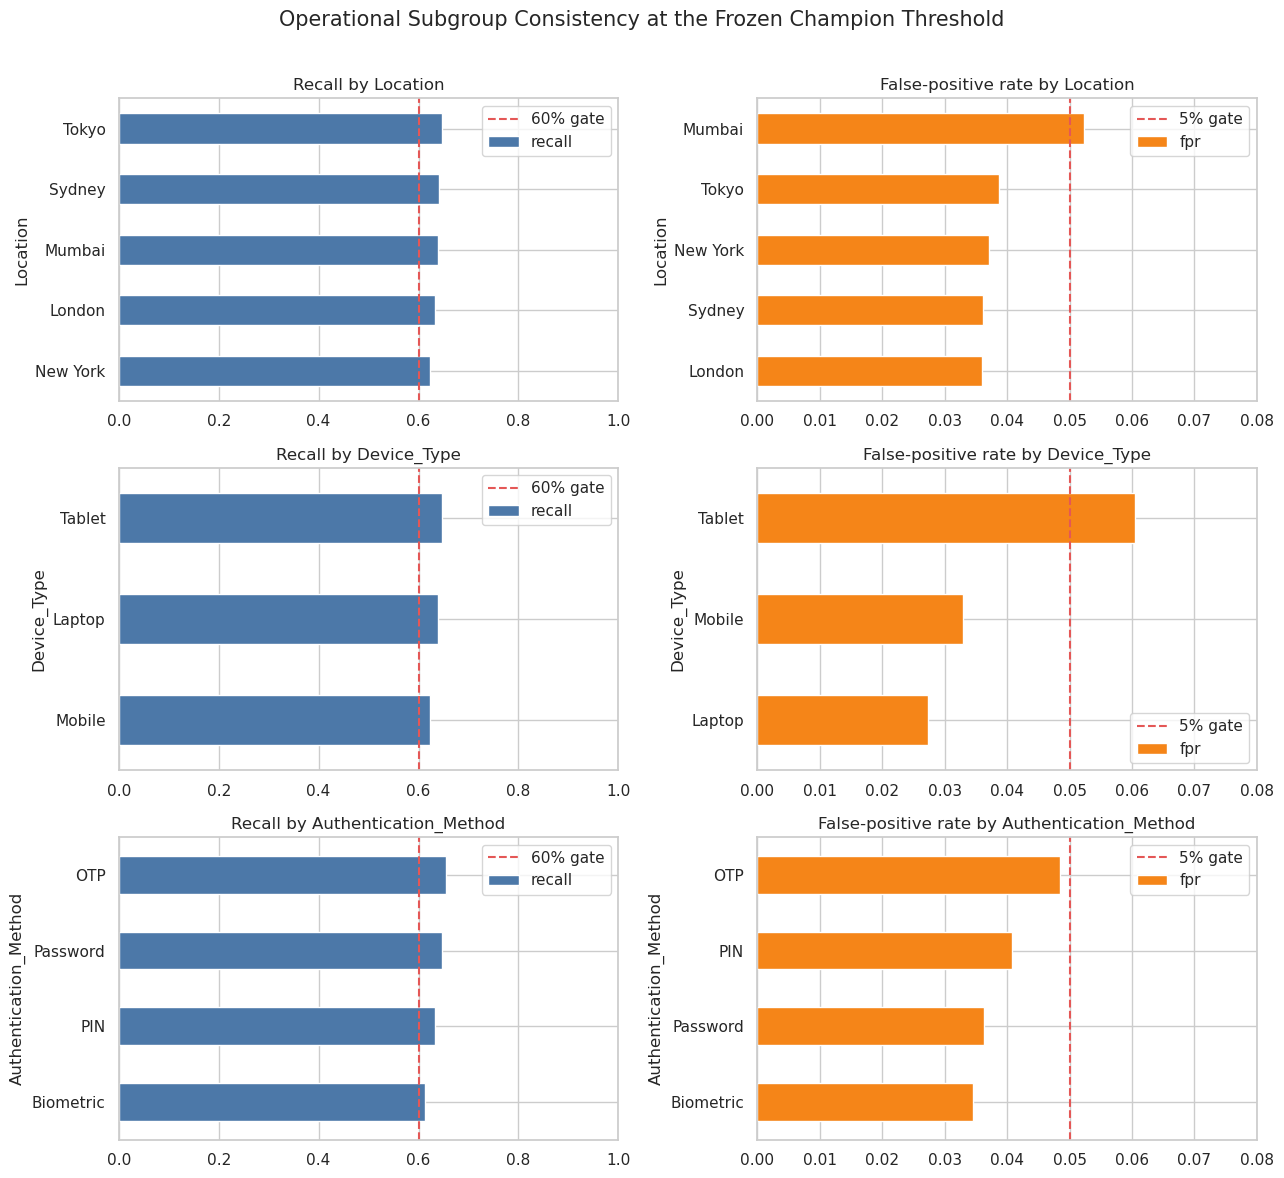

In [7]:
fig, axes = plt.subplots(len(FAIRNESS_COLUMNS), 2, figsize=(13, 12))

for row, column in enumerate(FAIRNESS_COLUMNS):
    table = fairness_tables[column]
    table["recall"].sort_values().plot.barh(
        ax=axes[row, 0], color="#4C78A8", title=f"Recall by {column}"
    )
    axes[row, 0].axvline(0.60, color="#E45756", linestyle="--", label="60% gate")
    axes[row, 0].set_xlim(0, 1)
    axes[row, 0].legend()

    table["fpr"].sort_values().plot.barh(
        ax=axes[row, 1], color="#F58518", title=f"False-positive rate by {column}"
    )
    axes[row, 1].axvline(0.05, color="#E45756", linestyle="--", label="5% gate")
    axes[row, 1].set_xlim(0, max(0.08, table["fpr"].max() * 1.2))
    axes[row, 1].legend()

fig.suptitle("Operational Subgroup Consistency at the Frozen Champion Threshold", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUTPUT_DIR / "fairness_recall_fpr_by_group.png", dpi=160, bbox_inches="tight")
plt.show()


### Fairness interpretation

1. **Location:** The recall gap across locations was **2.31 percentage points**, from **62.35% for New York** to **64.66% for Tokyo**. The FPR gap was **1.63 percentage points**. All locations met the 60% recall gate, but **Mumbai's 5.24% FPR exceeded the 5% gate**, meaning legitimate Mumbai transactions experienced the greatest risk of unnecessary fraud alerts or manual review. The other locations met both project gates.

2. **Device type:** The recall gap was **2.51 percentage points**, from **62.28% for Mobile** to **64.79% for Tablet**. The FPR gap was larger at **3.32 percentage points**. All device groups met the recall gate, but not all met the FPR gate: **Tablet reached 6.05% FPR**, compared with 2.73% for Laptop and 3.30% for Mobile. Tablet also had the lowest precision at 83.99%, so Tablet transactions carried a noticeably higher false-alert burden.

3. **Authentication method:** The largest disparity was the **4.20-percentage-point recall gap**, from **61.29% for Biometric** to **65.49% for OTP**. The FPR gap was **1.39 percentage points**, from 3.45% for Biometric to 4.85% for OTP. Nevertheless, every authentication group met both the 60% recall and 5% FPR gates.

4. **Overall interpretation and limitation:** The results identify operational disparities that deserve monitoring, particularly Mumbai and Tablet FPR. They do not establish demographic unfairness because Location, Device Type and Authentication Method are operational rather than protected demographic attributes, and the dataset is synthetic. Group sample sizes were broadly balanced, but real-world validation with appropriate protected attributes would still be required.


# Part B — Explainability with SHAP


### Approach justification

SHAP is used because the champion is an XGBoost classifier and the assignment requires both global and model-specific/local explanations. SHAP describes how features influenced the model output; it does **not** prove that a feature caused fraud.

The model pipeline first performs one-hot encoding and numeric passthrough. Therefore, SHAP is applied to the classifier using the exact transformed feature matrix and feature names from the fitted preprocessor.


In [8]:
if not hasattr(champion_model, "named_steps"):
    raise TypeError("Expected the champion to be a fitted scikit-learn Pipeline")

preprocessor = champion_model.named_steps["preprocess"]
classifier = champion_model.named_steps["classifier"]

# A fixed sample makes the evidence reproducible and keeps the demo responsive.
X_explain = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)
X_explain_transformed = preprocessor.transform(X_explain)
feature_names = np.array([
    name.replace("numeric__", "").replace("categorical__", "")
    for name in preprocessor.get_feature_names_out()
])

if hasattr(X_explain_transformed, "toarray"):
    X_explain_transformed = X_explain_transformed.toarray()

explainer = shap.TreeExplainer(classifier)
shap_explanation = explainer(X_explain_transformed)

# Normalize the occasional (rows, features, classes) representation.
if shap_explanation.values.ndim == 3:
    shap_matrix = shap_explanation.values[:, :, 1]
    base_values = np.asarray(shap_explanation.base_values)
    if base_values.ndim == 2:
        base_values = base_values[:, 1]
else:
    shap_matrix = shap_explanation.values
    base_values = shap_explanation.base_values

print("Explained rows:", len(X_explain))
print("Transformed features:", len(feature_names))
print("SHAP matrix shape:", shap_matrix.shape)


Explained rows: 1000
Transformed features: 40
SHAP matrix shape: (1000, 40)


,feature,mean_abs_shap
0,Failed_Transaction_Count_7d,2.271501
1,Transaction_Distance,0.041594
2,Daily_Transaction_Count,0.034924
3,Account_Balance,0.031843
4,Avg_Transaction_Amount_7d,0.025605
5,Transaction_Amount,0.025353
6,Card_Age,0.025142
7,Transaction_Month,0.023645
8,Device_Type_Tablet,0.022125
9,Transaction_DayOfWeek,0.014783


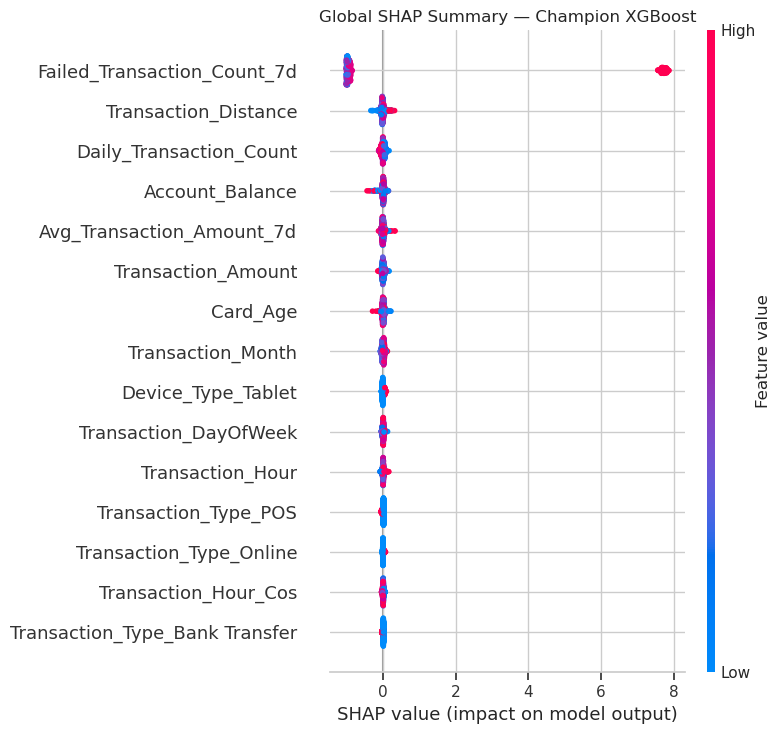

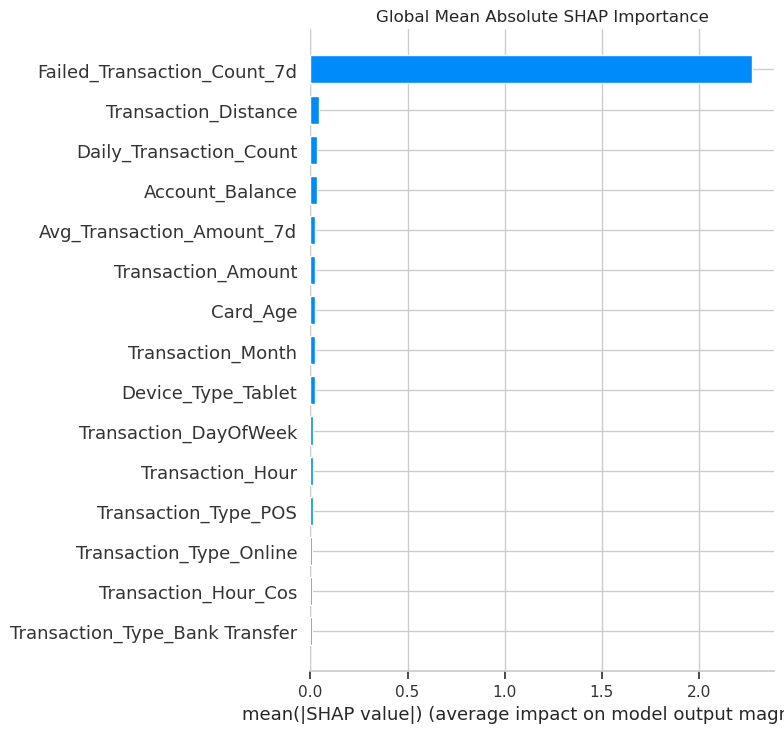

In [9]:
# Global mean absolute SHAP importance.
global_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
display(global_importance.head(15))
global_importance.to_csv(OUTPUT_DIR / "shap_global_importance.csv", index=False)

shap.summary_plot(
    shap_matrix,
    X_explain_transformed,
    feature_names=feature_names,
    max_display=15,
    show=False,
)
plt.title("Global SHAP Summary — Champion XGBoost")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_global_beeswarm.png", dpi=160, bbox_inches="tight")
plt.show()

shap.summary_plot(
    shap_matrix,
    X_explain_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.title("Global Mean Absolute SHAP Importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_global_bar.png", dpi=160, bbox_inches="tight")
plt.show()


### Global explanation interpretation

`Failed_Transaction_Count_7d` was overwhelmingly dominant, with mean absolute SHAP importance of **2.2715**. The next-ranked feature, `Transaction_Distance`, was only **0.0416**, making failed count roughly **55 times more influential** in this explanation sample. Other secondary contributors included daily transaction count, account balance, seven-day average amount, transaction amount, card age and transaction month.

This ranking is consistent with the dataset audit: the label could be almost reconstructed from a rule involving `Risk_Score` and `Failed_Transaction_Count_7d >= 4`. Although `Risk_Score` was excluded to reduce leakage, failed count was retained because the project assumes it is available before the current transaction. The extreme SHAP dominance therefore reveals a substantial dependency on this feature and should be presented as a model and dataset limitation.

`Device_Type_Tablet` ranked ninth with mean absolute SHAP importance of **0.0221**, which is relevant given the Tablet subgroup's elevated FPR. No Location, Card Type or Authentication Method indicator appeared among the top 15 global features. This reduces, but does not eliminate, concern about subgroup disparities because interactions and smaller effects can still influence individual decisions.

SHAP describes how the fitted model used these features; it does not establish that any feature caused fraud.


In [10]:
# Identify one true positive, false negative and false positive from the full test set.
prediction_cases = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "predicted": test_prediction,
    "fraud_probability": test_probability,
}, index=X_test.index)

case_queries = {
    "true_positive": "actual == 1 and predicted == 1",
    "false_negative": "actual == 1 and predicted == 0",
    "false_positive": "actual == 0 and predicted == 1",
}

case_indices = {}
for case_name, query in case_queries.items():
    matches = prediction_cases.query(query)
    if matches.empty:
        print(f"No {case_name.replace('_', ' ')} case exists at this threshold.")
    else:
        case_indices[case_name] = matches.index[0]

display(prediction_cases.loc[list(case_indices.values())])


,actual,predicted,fraud_probability
23889,1,1,0.999094
18866,1,0,0.157141
9991,0,1,0.199570


Case: True Positive
Original index: 23889
Actual: 1 | Predicted: 1
Fraud probability: 99.9094% | Threshold: 0.194696


,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Fraud_Label
23889,33.19,Bank Transfer,2023-08-08 06:07:00,62119.82,Mobile,Mumbai,Electronics,0,0,13,54.06,4,Amex,237,3832.68,Password,1


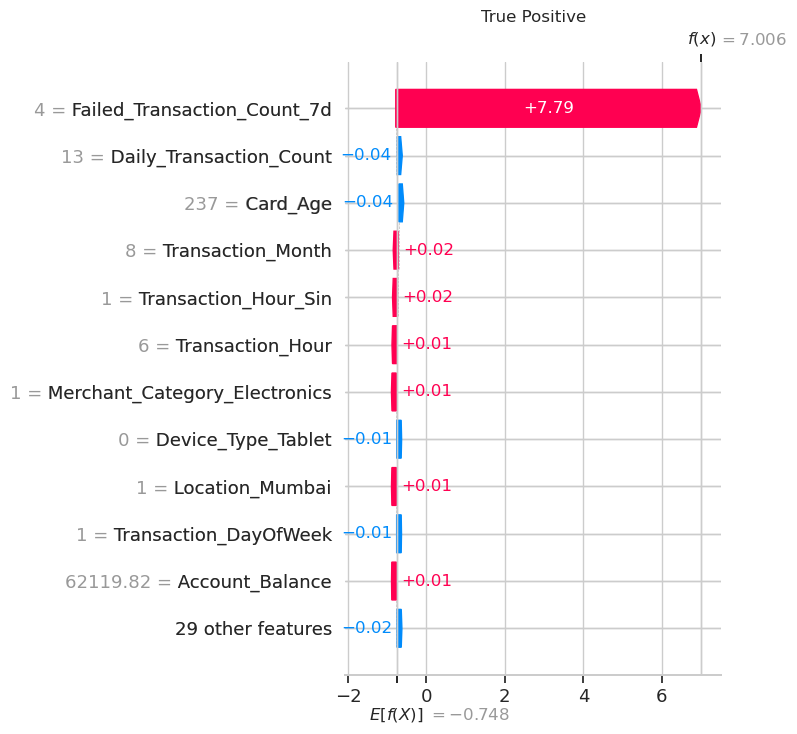

Case: False Negative
Original index: 18866
Actual: 1 | Predicted: 0
Fraud probability: 15.7141% | Threshold: 0.194696


,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Fraud_Label
18866,2.28,POS,2023-01-28 14:33:00,71602.44,Mobile,Sydney,Groceries,0,0,3,27.29,0,Discover,110,1899.05,Password,1


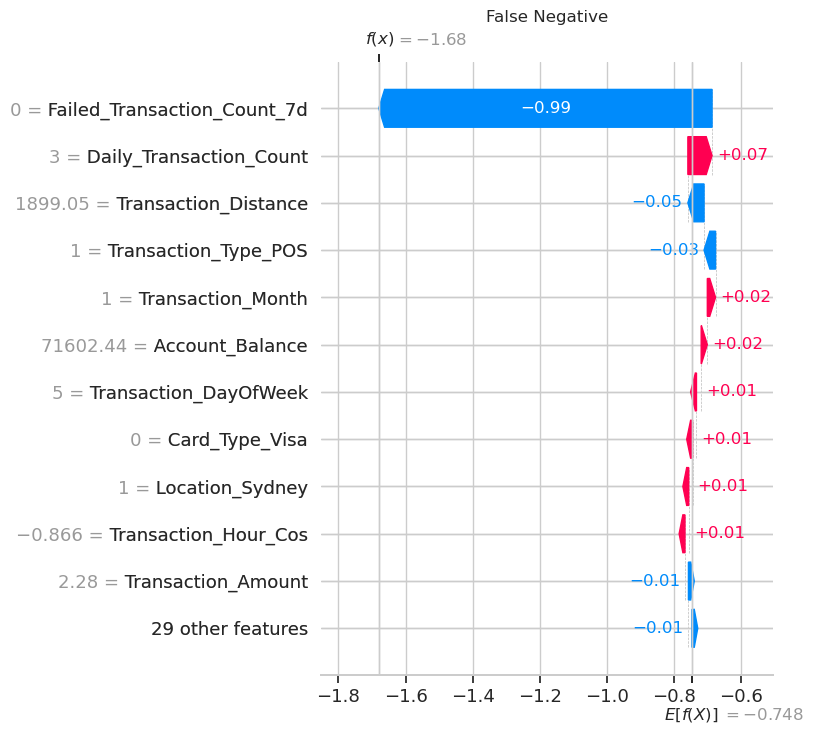

Case: False Positive
Original index: 9991
Actual: 0 | Predicted: 1
Fraud probability: 19.9570% | Threshold: 0.194696


,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Fraud_Label
9991,135.88,POS,2023-09-11 02:45:00,9870.13,Mobile,London,Groceries,0,0,3,492.29,1,Amex,30,4561.52,OTP,0


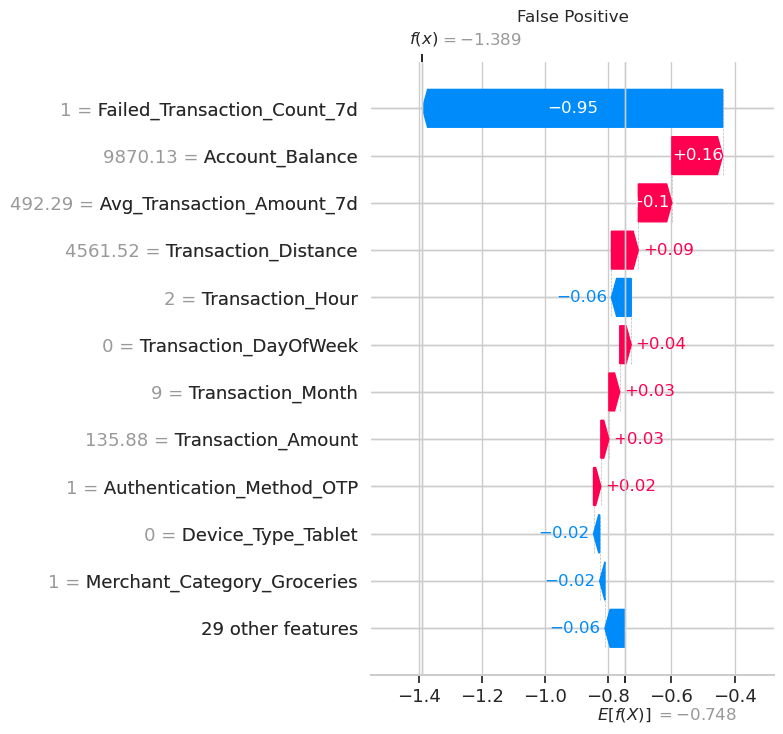

In [11]:
def explain_local_case(case_name, original_index):
    one_row = X_test.loc[[original_index]]
    transformed = preprocessor.transform(one_row)
    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()

    local = explainer(transformed)
    values = local.values
    bases = np.asarray(local.base_values)
    if values.ndim == 3:
        values = values[:, :, 1]
        if bases.ndim == 2:
            bases = bases[:, 1]

    probability = float(champion_model.predict_proba(one_row)[0, 1])
    actual = int(y_test.loc[original_index])
    predicted = int(probability >= BEST_THRESHOLD)

    print(f"Case: {case_name.replace('_', ' ').title()}")
    print(f"Original index: {original_index}")
    print(f"Actual: {actual} | Predicted: {predicted}")
    print(f"Fraud probability: {probability:.4%} | Threshold: {BEST_THRESHOLD:.6f}")
    display(raw_df.loc[[original_index], RAW_INFERENCE_COLUMNS + [TARGET_COLUMN]])

    explanation = shap.Explanation(
        values=values[0],
        base_values=np.ravel(bases)[0],
        data=transformed[0],
        feature_names=feature_names,
    )
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(case_name.replace("_", " ").title())
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"shap_local_{case_name}.png", dpi=160, bbox_inches="tight")
    plt.show()

for case_name, original_index in case_indices.items():
    explain_local_case(case_name, original_index)


### Local explanation interpretation

- **True positive (index 23889):** The transaction was correctly identified as fraud with **99.9094% probability**, far above the **19.4696% threshold**. `Failed_Transaction_Count_7d = 4` was the decisive contribution, adding approximately **+7.79** to the model output. Transaction month, hour-related features, Electronics merchant category and Mumbai location made only very small additional contributions. This example confirms that crossing the failed-count boundary strongly drives a fraud decision.

- **False negative (index 18866):** The actual fraud received only **15.7141% probability**, below the threshold. `Failed_Transaction_Count_7d = 0` was the dominant downward contribution at approximately **−0.99**. Transaction distance and POS transaction type also pushed the output downward, while daily transaction count contributed only about **+0.07** upward. This illustrates the risk of over-reliance on failed transaction history: fraud cases without prior failed transactions can be missed.

- **False positive (index 9991):** The legitimate transaction received **19.9570% probability**, only about **0.49 percentage points above the threshold**. `Failed_Transaction_Count_7d = 1` pushed the output downward by approximately **−0.95**, but account balance contributed about **+0.16**, transaction distance about **+0.09**, and day-of-week, month, amount and OTP authentication added smaller upward contributions. These combined effects moved a borderline legitimate case above the decision threshold. The practical impact could be an unnecessary decline, delay or manual fraud review.

These SHAP values describe contributions to the model predictions, not the real-world causes of fraud.


# Part C — Robustness


### Approach justification and criteria

Controlled copies of the held-out test set are perturbed while the model and threshold stay fixed. The existing project gates are reused as team-defined robustness criteria:

- recall ≥ 60%;
- FPR ≤ 5%;
- valid perturbed inputs do not crash the pipeline;
- malformed inputs should be rejected clearly rather than silently producing unreliable predictions.

These criteria are project choices; the assignment notice does not prescribe numerical robustness thresholds.


In [12]:
def evaluate_condition(name, frame, reference_prediction=test_prediction):
    try:
        probability = champion_model.predict_proba(frame)[:, 1]
        prediction = (probability >= BEST_THRESHOLD).astype(int)
        metrics = classification_metrics(y_test, prediction, probability)
        return {
            "condition": name,
            "status": "completed",
            "recall": metrics["recall"],
            "fpr": metrics["fpr"],
            "precision": metrics["precision"],
            "f1": metrics["f1"],
            "auc_roc": metrics["auc_roc"],
            "prediction_flip_rate": np.mean(prediction != reference_prediction),
            "mean_abs_probability_shift": np.mean(np.abs(probability - test_probability)),
            "recall_gate_60pct": metrics["recall"] >= 0.60,
            "fpr_gate_5pct": metrics["fpr"] <= 0.05,
            "error": "",
        }
    except Exception as error:
        return {
            "condition": name, "status": "rejected/error",
            "recall": np.nan, "fpr": np.nan, "precision": np.nan,
            "f1": np.nan, "auc_roc": np.nan,
            "prediction_flip_rate": np.nan,
            "mean_abs_probability_shift": np.nan,
            "recall_gate_60pct": False, "fpr_gate_5pct": False,
            "error": f"{type(error).__name__}: {error}",
        }

robustness_results = [evaluate_condition("Original test data", X_test.copy())]


In [13]:
# Test 1: reproducible ±5% multiplicative noise on measured continuous inputs.
rng = np.random.default_rng(RANDOM_STATE)
X_noise = X_test.copy()
NOISE_COLUMNS = [
    "Transaction_Amount", "Account_Balance",
    "Avg_Transaction_Amount_7d", "Transaction_Distance",
]
for column in NOISE_COLUMNS:
    multiplier = rng.normal(loc=1.0, scale=0.05, size=len(X_noise))
    X_noise[column] = (X_noise[column] * multiplier).clip(lower=0)

robustness_results.append(evaluate_condition("5% numeric noise", X_noise))


In [14]:
# Test 2: replace 10% of device values with an unseen category.
# OneHotEncoder(handle_unknown='ignore') should prevent a runtime crash,
# but prediction stability still needs to be measured.
X_unknown_device = X_test.copy()
unknown_index = X_unknown_device.sample(frac=0.10, random_state=RANDOM_STATE).index
X_unknown_device.loc[unknown_index, "Device_Type"] = "Unknown_Device"
robustness_results.append(
    evaluate_condition("10% unseen device category", X_unknown_device)
)


In [15]:
# Test 3: sensitivity around the dataset's important failed-count boundary.
X_failed_3 = X_test.copy()
X_failed_4 = X_test.copy()
X_failed_3["Failed_Transaction_Count_7d"] = 3
X_failed_4["Failed_Transaction_Count_7d"] = 4

prob_failed_3 = champion_model.predict_proba(X_failed_3)[:, 1]
prob_failed_4 = champion_model.predict_proba(X_failed_4)[:, 1]
pred_failed_3 = (prob_failed_3 >= BEST_THRESHOLD).astype(int)
pred_failed_4 = (prob_failed_4 >= BEST_THRESHOLD).astype(int)

failed_count_sensitivity = pd.Series({
    "mean_probability_at_3": prob_failed_3.mean(),
    "mean_probability_at_4": prob_failed_4.mean(),
    "mean_probability_jump_3_to_4": (prob_failed_4 - prob_failed_3).mean(),
    "prediction_change_rate_3_to_4": np.mean(pred_failed_3 != pred_failed_4),
})
display(failed_count_sensitivity.to_frame("result").style.format("{:.4%}"))
failed_count_sensitivity.to_csv(OUTPUT_DIR / "failed_count_boundary_sensitivity.csv")

robustness_results.append(evaluate_condition("Failed count forced to 3", X_failed_3))
robustness_results.append(evaluate_condition("Failed count forced to 4", X_failed_4))


,result
mean_probability_at_3,15.6618%
mean_probability_at_4,99.9072%
mean_probability_jump_3_to_4,84.2455%
prediction_change_rate_3_to_4,94.0100%


In [16]:
# Test 4: missing value. The current pipeline has no imputer, so a clear
# rejection/error is an expected finding rather than silent tolerance.
X_missing = X_test.copy()
missing_index = X_missing.sample(frac=0.05, random_state=RANDOM_STATE).index
X_missing.loc[missing_index, "Transaction_Amount"] = np.nan
robustness_results.append(
    evaluate_condition("5% missing Transaction_Amount", X_missing)
)

# Test 5: out-of-range but numeric values. This may run successfully because
# model-level range validation is not currently implemented.
X_out_of_range = X_test.copy()
edge_index = X_out_of_range.sample(frac=0.05, random_state=RANDOM_STATE).index
X_out_of_range.loc[edge_index, "Transaction_Amount"] = -100.0
X_out_of_range.loc[edge_index, "Transaction_Distance"] = 10_000.0
X_out_of_range.loc[edge_index, "Daily_Transaction_Count"] = 99
robustness_results.append(
    evaluate_condition("5% out-of-range numeric values", X_out_of_range)
)


In [17]:
# Test 6: raw-contract and timestamp validation independent of X_test,
# because timestamp engineering occurs before the model feature matrix.
def validate_and_prepare_raw_record(record):
    missing = [column for column in RAW_INFERENCE_COLUMNS if column not in record]
    if missing:
        raise ValueError(f"Missing required fields: {missing}")
    empty = [
        column for column in RAW_INFERENCE_COLUMNS
        if record[column] is None or record[column] == ""
    ]
    if empty:
        raise ValueError(f"Empty required fields: {empty}")
    # Explicit check recommended for the Gradio/API layer.
    pd.to_datetime(record["Timestamp"], errors="raise")
    if float(record["Transaction_Amount"]) < 0:
        raise ValueError("Transaction_Amount must be non-negative")
    if float(record["Transaction_Distance"]) < 0:
        raise ValueError("Transaction_Distance must be non-negative")
    return True

sample_record = json.loads(
    raw_df.loc[[X_test.index[0]], RAW_INFERENCE_COLUMNS].to_json(orient="records")
)[0]

contract_tests = []
for test_name, mutation in {
    "valid_record": lambda record: record,
    "missing_amount": lambda record: {k: v for k, v in record.items() if k != "Transaction_Amount"},
    "invalid_timestamp": lambda record: {**record, "Timestamp": "not-a-date"},
    "negative_amount": lambda record: {**record, "Transaction_Amount": -100.0},
}.items():
    try:
        validate_and_prepare_raw_record(mutation(sample_record.copy()))
        outcome, message = "accepted", ""
    except Exception as error:
        outcome, message = "safely rejected", f"{type(error).__name__}: {error}"
    contract_tests.append({"test": test_name, "outcome": outcome, "message": message})

contract_table = pd.DataFrame(contract_tests)
display(contract_table)
contract_table.to_csv(OUTPUT_DIR / "raw_contract_robustness.csv", index=False)


,test,outcome,message
0,valid_record,accepted,
1,missing_amount,safely rejected,ValueError: Missing required fields: ['Transac...
2,invalid_timestamp,safely rejected,DateParseError: Unknown datetime string format...
3,negative_amount,safely rejected,ValueError: Transaction_Amount must be non-neg...


In [18]:
robustness_table = pd.DataFrame(robustness_results)

baseline_row = robustness_table.iloc[0]
for metric in ["recall", "fpr", "precision", "f1"]:
    robustness_table[f"delta_{metric}"] = robustness_table[metric] - baseline_row[metric]

display(robustness_table.style.format({
    "recall": "{:.2%}", "fpr": "{:.2%}", "precision": "{:.2%}",
    "f1": "{:.2%}", "auc_roc": "{:.2%}",
    "prediction_flip_rate": "{:.2%}",
    "mean_abs_probability_shift": "{:.4%}",
    "delta_recall": "{:+.2%}", "delta_fpr": "{:+.2%}",
    "delta_precision": "{:+.2%}", "delta_f1": "{:+.2%}",
}))
robustness_table.to_csv(OUTPUT_DIR / "robustness_summary.csv", index=False)


,condition,status,recall,fpr,precision,f1,auc_roc,prediction_flip_rate,mean_abs_probability_shift,recall_gate_60pct,fpr_gate_5pct,error,delta_recall,delta_fpr,delta_precision,delta_f1
0,Original test data,completed,63.68%,4.01%,88.27%,73.98%,81.45%,0.00%,0.0000%,True,True,,+0.00%,+0.00%,+0.00%,+0.00%
1,5% numeric noise,completed,63.37%,4.45%,87.08%,73.36%,81.10%,2.10%,0.5114%,True,True,,-0.31%,+0.44%,-1.18%,-0.63%
2,10% unseen device category,completed,63.62%,3.92%,88.48%,74.02%,81.47%,0.10%,0.0330%,True,True,,-0.06%,-0.09%,+0.22%,+0.03%
3,Failed count forced to 3,completed,6.50%,5.75%,34.89%,10.97%,51.12%,20.35%,17.2004%,False,False,,-57.17%,+1.74%,-53.37%,-63.02%
4,Failed count forced to 4,completed,100.00%,100.00%,32.13%,48.63%,50.82%,76.82%,67.9115%,True,False,,+36.32%,+95.99%,-56.14%,-25.35%
5,5% missing Transaction_Amount,completed,63.62%,3.93%,88.45%,74.00%,81.41%,0.09%,0.0927%,True,True,,-0.06%,-0.07%,+0.18%,+0.02%
6,5% out-of-range numeric values,completed,64.71%,6.60%,82.27%,72.44%,81.39%,2.11%,0.2069%,True,False,,+1.03%,+2.59%,-5.99%,-1.54%


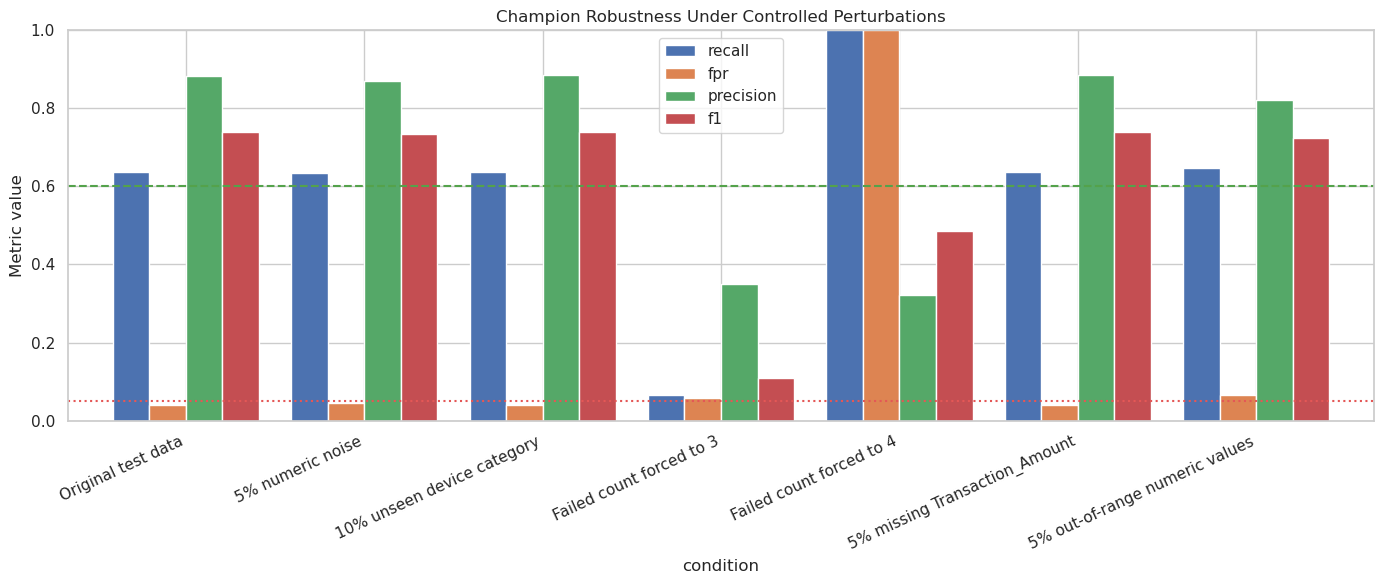

In [19]:
plot_data = robustness_table[robustness_table["status"] == "completed"].copy()
plot_data = plot_data.set_index("condition")[["recall", "fpr", "precision", "f1"]]

ax = plot_data.plot.bar(figsize=(14, 6), width=0.82)
ax.axhline(0.60, color="#54A24B", linestyle="--", label="60% recall gate")
ax.axhline(0.05, color="#E45756", linestyle=":", label="5% FPR gate")
ax.set_ylabel("Metric value")
ax.set_title("Champion Robustness Under Controlled Perturbations")
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "robustness_metrics.png", dpi=160, bbox_inches="tight")
plt.show()


### Robustness interpretation

1. **Numerical noise:** With 5% noise applied to continuous inputs, the prediction-flip rate was **2.10%** and F1 decreased by **0.63 percentage points**, from 73.98% to 73.36%. Recall decreased by 0.31 points and FPR increased by 0.44 points. Both project gates still passed, indicating reasonable—but not perfect—stability under small numerical variation.

2. **Unseen device category:** The test completed without crashing because the encoder uses `handle_unknown="ignore"`. Only **0.10%** of predictions changed, the mean absolute probability shift was **0.0330%**, and F1 increased by 0.03 points. Both gates remained satisfied, so the model was stable under this particular unseen-category test.

3. **Failed-count boundary:** Moving `Failed_Transaction_Count_7d` from 3 to 4 changed **94.01% of decisions** and increased mean fraud probability by **84.25 percentage points**, from 15.66% to 99.91%. This indicates **extremely high sensitivity** to the known rule boundary. When all records were forced to 3, recall fell to 6.50%; when forced to 4, both recall and FPR became 100%. These are deliberately severe stress tests, but they confirm that failed count dominates model behaviour.

4. **Missing values:** At the engineered-model level, XGBoost accepted 5% missing `Transaction_Amount` values: only 0.09% of predictions changed and both gates still passed. At the raw request boundary, however, a missing amount was **safely rejected**. Production should retain explicit required-field validation instead of relying on the model's internal missing-value handling.

5. **Out-of-range values:** The model accepted negative transaction amounts, very large distances and daily counts of 99. FPR increased from 4.01% to **6.60%**, failing the 5% gate; precision fell by 5.99 points and F1 fell by 1.54 points. Application-level range checks are therefore required before production inference.

6. **Malformed requests:** Missing amounts, invalid timestamps and negative amounts were all safely rejected by the raw-contract validator, while a valid record was accepted. This demonstrates the desired fail-fast behaviour and should be incorporated into the Gradio/API input-validation layer.

Overall, the champion was stable under small numerical noise and an unseen device label, but it was highly sensitive to the failed-count boundary and insufficiently protected against out-of-range numeric inputs at the model layer.


# 5. Final responsible-AI summary


In [20]:
summary = {
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "model_uri": BEST_MODEL_URI,
    "algorithm": champion.get("algorithm"),
    "frozen_threshold": BEST_THRESHOLD,
    "test_rows": len(X_test),
    "baseline_metrics": baseline,
    "fairness_gap_summary": gap_table.to_dict(orient="index"),
    "top_15_shap_features": global_importance.head(15).to_dict(orient="records"),
    "robustness_results": robustness_table.replace({np.nan: None}).to_dict(orient="records"),
    "contract_tests": contract_table.to_dict(orient="records"),
    "limitations": [
        "No demographic protected attributes are available.",
        "The dataset is synthetic and cannot establish real-world fairness.",
        "SHAP explains model behavior, not causation.",
        "Robustness criteria are team-defined prototype criteria.",
    ],
}

summary_path = OUTPUT_DIR / "responsible_ai_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, default=float), encoding="utf-8")

print("Responsible-AI audit complete.")
print("Evidence directory:", OUTPUT_DIR.resolve())
print("Summary:", summary_path)
print("\nFiles created:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)


Responsible-AI audit complete.
Evidence directory: /home/sagemaker-user/ITI113-MLOps-Team07-FraudDetectionApp/responsible_ai_outputs
Summary: responsible_ai_outputs/responsible_ai_summary.json

Files created:
 - failed_count_boundary_sensitivity.csv
 - fairness_authentication_method.csv
 - fairness_device_type.csv
 - fairness_gap_summary.csv
 - fairness_location.csv
 - fairness_recall_fpr_by_group.png
 - raw_contract_robustness.csv
 - responsible_ai_summary.json
 - robustness_metrics.png
 - robustness_summary.csv
 - shap_global_bar.png
 - shap_global_beeswarm.png
 - shap_global_importance.csv
 - shap_local_false_negative.png
 - shap_local_false_positive.png
 - shap_local_true_positive.png


## Demo conclusion

> We evaluated the same leakage-safe XGBoost champion at its frozen **19.4696%** validation-selected threshold. On the held-out test set, it achieved **63.68% recall**, **4.01% FPR**, **88.27% precision** and **73.98% F1**, satisfying the project deployment gates. Fairlearn found moderate operational subgroup gaps, but Mumbai's **5.24% FPR** and Tablet's **6.05% FPR** exceeded the project limit and warrant monitoring. SHAP showed that seven-day failed transaction count overwhelmingly dominated the model, and moving that count from 3 to 4 changed **94.01%** of decisions. The model remained stable under 5% numerical noise and an unseen device category, but out-of-range values raised FPR to **6.60%**, demonstrating the need for stronger input-range validation. Because the dataset is synthetic and contains no protected demographic attributes, these results assess operational consistency rather than demographic fairness; SHAP also explains model behaviour rather than causation.
